# Zomato data anaylsis project

- step_1: Import Librares

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# import dataset
df = pd.read_csv(r"C:\Users\user\Desktop\AI automation\project_3\Zomato data .csv")
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [18]:
df.isnull().sum() 

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [20]:
# convert the datatype of column -rate
def handleRate(value):
    value = str(value).split('/')
    value = value[0]
    return float(value)

df['rate'] = df['rate'].apply(handleRate)
print(df['rate'])

0      4.1
1      4.1
2      3.8
3      3.7
4      3.8
      ... 
143    3.3
144    3.3
145    4.0
146    3.0
147    3.9
Name: rate, Length: 148, dtype: float64


## type of restruant

In [21]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


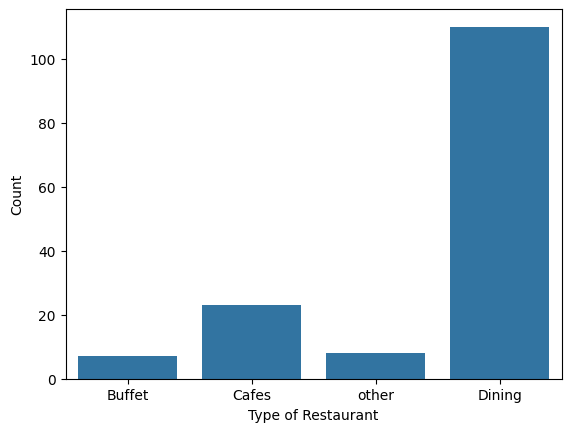

In [22]:
sns.countplot(x=df['listed_in(type)'])
plt.xlabel('Type of Restaurant')
plt.ylabel('Count')
plt.show()

- conclusion - majority of the resturant falls in dinning category

In [23]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


Text(0, 0.5, 'Votes')

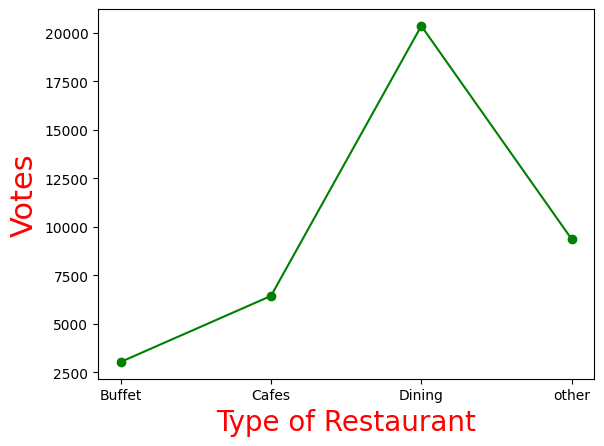

In [24]:
# draw aline plot between list_in(type) and rate
grouped_data =df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})
plt.plot(result, c='green', marker='o')
plt.xlabel('Type of Restaurant', c='red', size=20)
plt.ylabel('Votes', c='red', size=22)

- Dinning resturant has recieved maximum vote

In [25]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


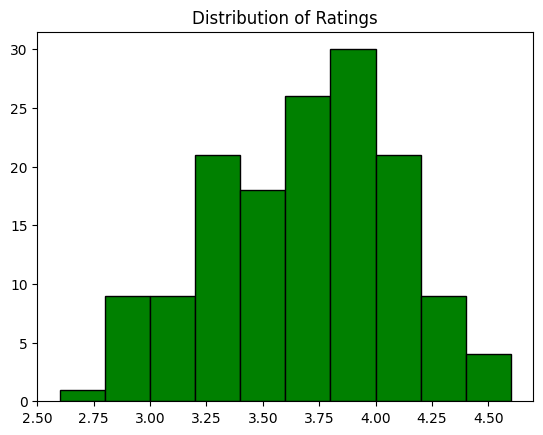

In [26]:
# plot a histogram
plt.hist(df['rate'], bins=10, color='green', edgecolor='black')
plt.title('Distribution of Ratings')
plt.show()

- conclusion the majority resturant recieves rating from 3.5 to4

# Average order spending by couples

In [27]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


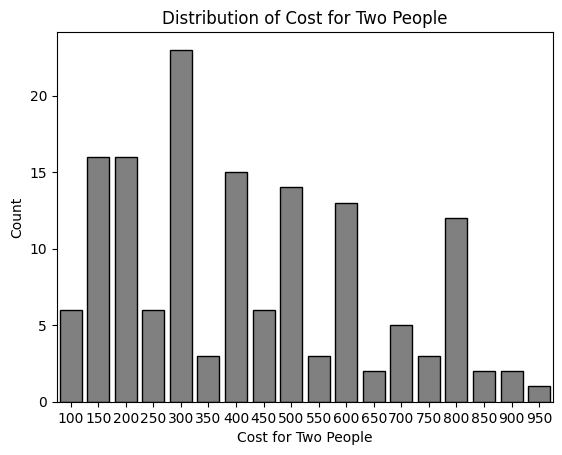

In [28]:
# draw a countplot for count the cost of two people
couple_data =df['approx_cost(for two people)']
sns.countplot(x=couple_data, color='grey', edgecolor='black')
plt.xlabel('Cost for Two People')
plt.ylabel('Count')
plt.title('Distribution of Cost for Two People')
plt.show()

- conclusion the majority of couples prefer resturant with an appronimate cost of 300 rupess

# Which mode recives maximum rating

In [29]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


<Axes: xlabel='online_order', ylabel='rate'>

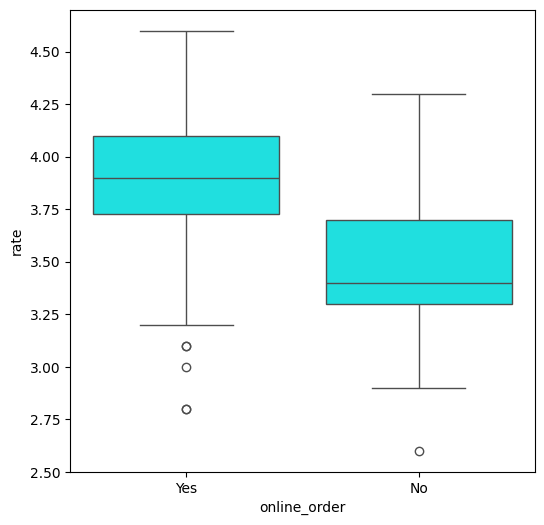

In [32]:
# draw a boxplot
plt.figure(figsize=(6, 6))
sns.boxplot(x='online_order', y='rate', data=df, color='cyan')

- conclusion: offline order recieved lower order

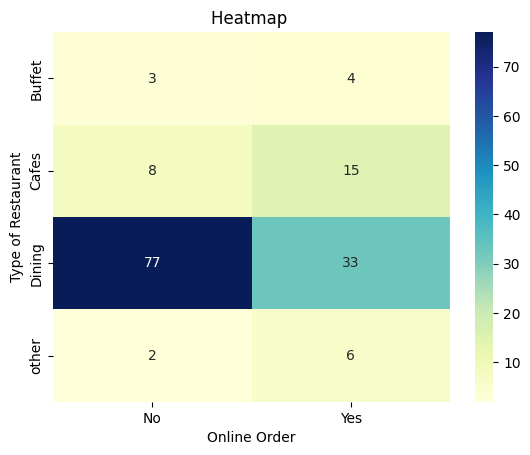

In [33]:
# Draw a heatmap  for list_in(type) and online_order
pivot_table =df.pivot_table(index='listed_in(type)', columns='online_order',  aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu",fmt='d')
plt.title('Heatmap ')
plt.xlabel('Online Order')
plt.ylabel('Type of Restaurant')
plt.show()

📊 Zomato Data Analysis Project 

Q1. What is the objective of this Zomato data analysis project?
✅ Answer:
The objective of this project is to analyze restaurant data from Zomato to understand customer preferences, restaurant ratings, voting patterns, online ordering behavior, and cost distribution using Python data analysis and visualization techniques.

Q2. Which Python libraries were used in this project?
✅ Answer:
- Pandas → Data manipulation and analysis
- NumPy → Numerical computations
- Matplotlib → Data visualization
- Seaborn → Advanced statistical visualizations

Q3. How was the dataset loaded into Python?
✅ Answer:
The dataset was loaded using Pandas:
df = pd.read_csv("Zomato data.csv")

Q4. How did you check for missing values in the dataset?
✅ Answer:
The isnull().sum() function was used to identify missing values in each column.

Q5. Why was df.info() used?
✅ Answer:
df.info() was used to understand:
- Number of rows and columns
- Data types of each column
- Non-null values
- Memory usage

Q6. Why was the 'rate' column transformed?
✅ Answer:
The rating values were stored in the format "4.1/5". To perform numerical analysis, the ratings were converted into float values by extracting the first part before '/'.

Q7. How was the rating column cleaned?
✅ Answer:
A custom function was created:

def handleRate(value):
    value = str(value).split('/')
    value = value[0]
    return float(value)

This converted ratings into numerical format.

Q8. What visualization was used to analyze restaurant types?
✅ Answer:
A Count Plot was used to show the number of restaurants in each category of listed_in(type).

Q9. What insight can be obtained from the restaurant type count plot?
✅ Answer:
The plot identifies which restaurant category (Dining, Cafes, Delivery, etc.) has the highest number of restaurants.

Q10. Why was a line plot created between restaurant type and votes?
✅ Answer:
The line plot was used to analyze the total customer votes received by each restaurant category.

Q11. What insight does the votes analysis provide?
✅ Answer:
It shows which restaurant category receives the highest customer engagement and popularity based on votes.

Q12. Why was groupby() used in the project?
✅ Answer:
groupby() was used to aggregate votes according to restaurant type.

Example:
grouped_data = df.groupby('listed_in(type)')['votes'].sum()

Q13. Why was a histogram created for ratings?
✅ Answer:
The histogram helps visualize the distribution of restaurant ratings and identifies the most common rating ranges.

Q14. What insight can be derived from the rating histogram?
✅ Answer:
Most restaurants generally fall within a specific rating range, helping identify overall customer satisfaction trends.

Q15. Why was the 'approx_cost(for two people)' column analyzed?
✅ Answer:
To understand the most common spending range for customers dining at restaurants.

Q16. What visualization was used for cost analysis?
✅ Answer:
A Count Plot was used to display the frequency of different cost categories.

Q17. What insight does the cost distribution provide?
✅ Answer:
It helps identify the most affordable and most common pricing ranges preferred by customers.

Q18. Why was a boxplot used in the project?
✅ Answer:
The boxplot was used to compare restaurant ratings based on online ordering availability.

Q19. Which variables were compared in the boxplot?
✅ Answer:
- online_order
- rate

Q20. What insight can be obtained from the boxplot?
✅ Answer:
It helps determine whether restaurants offering online ordering tend to have higher ratings compared to those that do not.

Q21. Why was a heatmap created?
✅ Answer:
The heatmap was used to visualize the relationship between restaurant type and online ordering availability.

Q22. How was the heatmap data prepared?
✅ Answer:
A pivot table was created:

pivot_table = df.pivot_table(
    index='listed_in(type)',
    columns='online_order',
    aggfunc='size',
    fill_value=0
)

Q23. What insight does the heatmap provide?
✅ Answer:
The heatmap shows which restaurant categories are more likely to offer online ordering services.

Q24. What data preprocessing techniques were used in the project?
✅ Answer:
- Missing value checking
- Data type conversion
- Feature cleaning
- Data aggregation

Q25. What are the key business insights generated from this project?
✅ Answer:
1. Most popular restaurant category.
2. Restaurant categories receiving maximum votes.
3. Distribution of restaurant ratings.
4. Customer spending patterns for two people.
5. Impact of online ordering on ratings.
6. Relationship between restaurant type and online ordering.

Q26. What skills does this project demonstrate?
✅ Answer:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Statistical Analysis
- Business Insight Generation
- Pandas
- NumPy
- Matplotlib
- Seaborn

Q27. What could be added to improve this project?
✅ Answer:
- Interactive dashboards using Tableau or Power BI
- Correlation analysis
- Rating prediction models
- Customer segmentation
- Geographic analysis using maps
- Sentiment analysis of reviews

Q28. What is the final conclusion of the project?
✅ Answer:
The analysis helps understand customer preferences, restaurant popularity, rating trends, online ordering behavior, and pricing patterns, enabling restaurant owners and business stakeholders to make data-driven decisions.